In [1]:
import pandas as pd

# Task 1

In [2]:
df = pd.read_csv("students.csv")
print("First 5 rows:")
df.head()

First 5 rows:


,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


In [5]:
print(f"Shape (rows, columns) : {df.shape}")
print(f"datatypes : \n{df.dtypes}")

Shape (rows, columns) : (15, 9)
datatypes : 
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


In [6]:
df.info()# can be used instead above cell

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   name                 15 non-null     str    
 1   math                 15 non-null     int64  
 2   science              15 non-null     int64  
 3   english              15 non-null     int64  
 4   history              15 non-null     int64  
 5   pe                   15 non-null     int64  
 6   attendance_pct       15 non-null     int64  
 7   study_hours_per_day  15 non-null     float64
 8   passed               15 non-null     int64  
dtypes: float64(1), int64(7), str(1)
memory usage: 1.2 KB


In [7]:
print("Summary statistics:")
df.describe()

Summary statistics:


,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,65.000000,66.733333,66.200000,63.400000,74.800000,75.800000,2.893333,0.600000
std,20.060622,18.967893,17.773174,16.936014,16.657045,14.722189,1.658944,0.507093
min,30.000000,35.000000,40.000000,28.000000,45.000000,50.000000,0.500000,0.000000
25%,51.500000,53.500000,49.000000,53.500000,61.000000,63.500000,1.650000,0.000000
50%,65.000000,65.000000,70.000000,62.000000,75.000000,78.000000,2.800000,1.000000
75%,80.000000,77.000000,81.000000,73.500000,89.000000,86.500000,3.900000,1.000000
max,95.000000,98.000000,91.000000,92.000000,97.000000,98.000000,6.000000,1.000000


In [9]:
df['passed_label'] = df['passed'].map({1: 'Pass', 0: 'Fail'})
print("Pass/Fail count:")
df['passed_label'].value_counts()

Pass/Fail count:


passed_label
Pass    9
Fail    6
Name: count, dtype: int64

In [12]:
subject_cols = ['math', 'science', 'english', 'history', 'pe']
passing_avg = df[df['passed'] == 1][subject_cols].mean()
failing_avg = df[df['passed'] == 0][subject_cols].mean()

print(f"Average scores (Passing Students):\n {passing_avg}")
print(f"Average scores (failing Students):\n {failing_avg}")

Average scores (Passing Students):
 math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64
Average scores (failing Students):
 math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64


In [13]:
df['avg_score']=df[['math', 'science', 'english', 'history', 'pe']].mean(axis= 1)
df.head(3)

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed,passed_label,avg_score
0,Alice,88,92,76,80,95,92,4.5,1,Pass,86.2
1,Bob,42,55,48,50,60,65,1.2,0,Fail,51.0
2,Charlie,75,70,80,68,88,85,3.0,1,Pass,76.2


In [17]:
a=0
for i in df['avg_score']:
    if i==df['avg_score'].max():
        print(f"   Topper     : {df['name'][a]} \nAverage Score : {i}")
    a+=1
#print(df.loc[df['avg_score'].idxmax()]) # used when we want to see topper full data

   Topper     : Diana 
Average Score : 94.0


# Task 2

In [18]:
import matplotlib.pyplot as plt

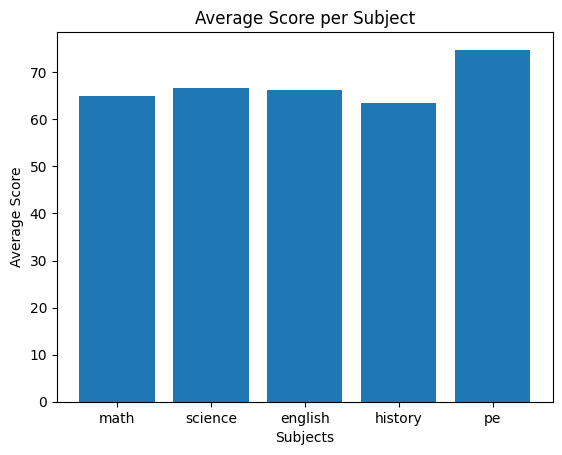

In [22]:
# 1. Bar Chart — Average score per subject
avg_scores=df[['math', 'science', 'english', 'history', 'pe']].mean()
plt.figure()
plt.bar(avg_scores.index, avg_scores.values, label="Average Score")
plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")

plt.savefig("plot1_bar.png")
plt.show()

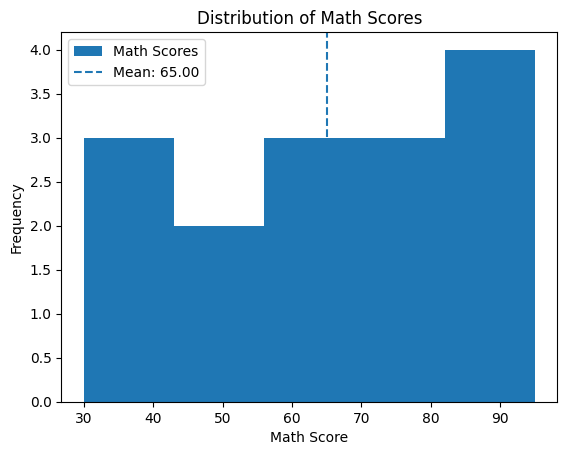

In [25]:
# 2. Histogram — Math score distribution
plt.hist(df['math'], bins=5, label="Math Scores")

mean_math = df['math'].mean()
plt.axvline(mean_math, linestyle='dashed', label=f"Mean: {mean_math:.2f}")

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.legend()

plt.savefig("plot2_hist.png")
plt.show()

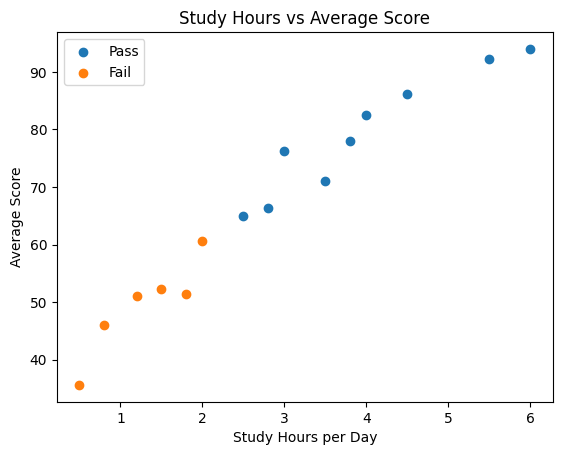

In [31]:
# 3. Scatter Plot — Study Hours vs Avg Score
pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]

plt.figure()
plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], label="Pass")
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], label="Fail")

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot3_scatter.png")
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_17116\3544263123.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])


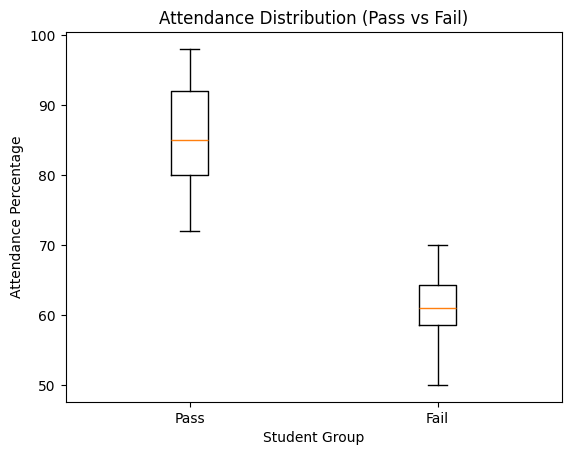

In [33]:
# 4. Box Plot — Attendance (Pass vs Fail)
pass_attendance = pass_df['attendance_pct'].tolist()
fail_attendance = fail_df['attendance_pct'].tolist()

plt.figure()
plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])

plt.title("Attendance Distribution (Pass vs Fail)")
plt.xlabel("Student Group")
plt.ylabel("Attendance Percentage")

plt.savefig("plot4_box.png")
plt.show()

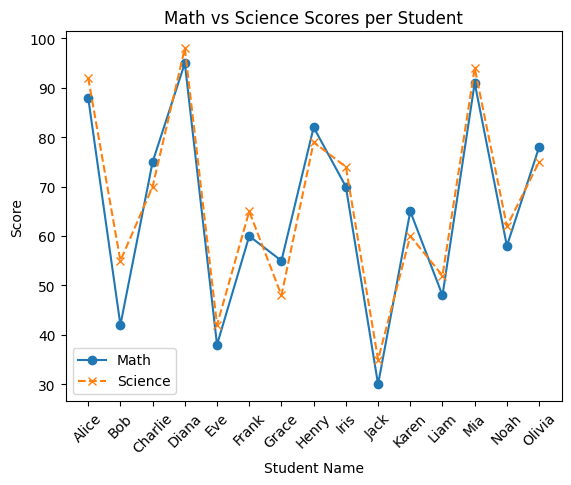

In [36]:
# 5. Line Plot — Math vs Science per Student
# -----------------------------
plt.figure()

plt.plot(df['name'], df['math'], marker='o', linestyle='-', label="Math")
plt.plot(df['name'], df['science'], marker='x', linestyle='--', label="Science")

plt.title("Math vs Science Scores per Student")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()

plt.savefig("plot5_line.png")
plt.show()

# Task 3

In [37]:
import seaborn as sns

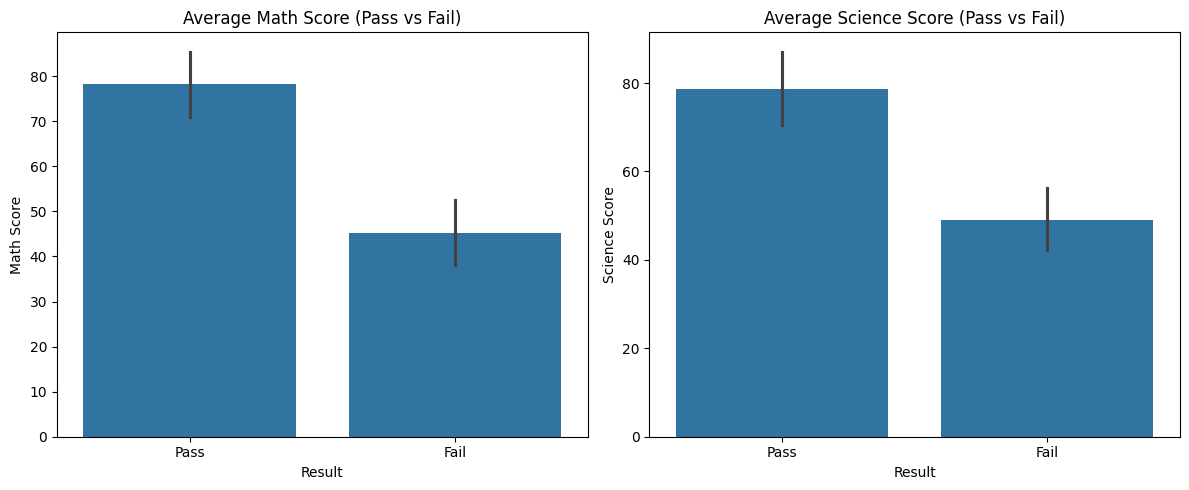

In [46]:
# 1. Seaborn Bar Plots (Math & Science)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=df, x='passed_label', y='math', ax=ax1)
ax1.set_title("Average Math Score (Pass vs Fail)")
ax1.set_xlabel("Result")
ax1.set_ylabel("Math Score")

sns.barplot(data=df, x='passed_label', y='science', ax=ax2)
ax2.set_title("Average Science Score (Pass vs Fail)")
ax2.set_xlabel("Result")
ax2.set_ylabel("Science Score")

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()

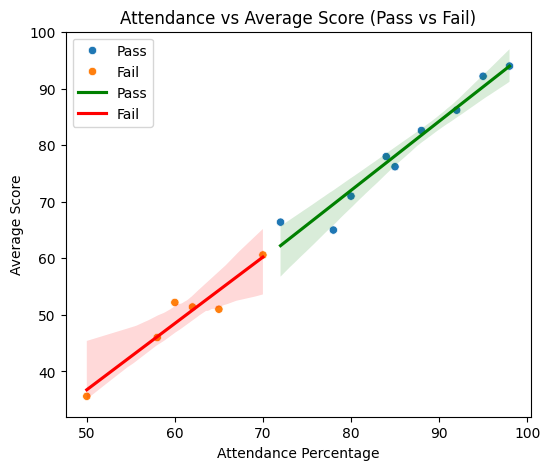

In [49]:
# 2. Seaborn Scatter + Regression Lines

plt.figure(figsize=(6, 5))

# Scatter plot with hue
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed_label')

# Regression lines for each group
sns.regplot(data=df[df['passed'] == 1], x='attendance_pct', y='avg_score', scatter=False, label='Pass', color='green')

sns.regplot(data=df[df['passed'] == 0], x='attendance_pct', y='avg_score', scatter=False, label='Fail',
color='red')

plt.title("Attendance vs Average Score (Pass vs Fail)")
plt.xlabel("Attendance Percentage")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot7_seaborn_scatter.png")
plt.show()

In [50]:
#"""Seaborn is much easier to create visually appealing plots with less code, especially for grouped data like Pass vs Fail. The built-in handling of categories and statistical aggregation (like mean in barplot) reduces manual work. However, Matplotlib gives more fine-grained control, but requires more effort for styling and grouping compared to Seaborn."""

# Task 4

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [21]:
df.columns

Index(['name', 'math', 'science', 'english', 'history', 'pe', 'attendance_pct',
       'study_hours_per_day', 'passed', 'passed_label', 'avg_score'],
      dtype='str')

In [22]:
# Step 1 — Prepare Data

features = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']

x = df[features]   # exclude ['name', 'avg_score', 'passed_label']
y = df['passed']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [23]:
# Step 2 — Train a Model

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

train_acc = model.score(X_train_scaled, y_train)
print(f"Training Accuracy: {train_acc:.2f}")

Training Accuracy: 1.00


In [24]:
# Step 3 — Evaluate the Model:

y_pred = model.predict(X_test_scaled)

test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_acc:.2f}\n")

# Show predictions with names
print("Predictions on Test Set:")
names = df.loc[X_test.index, 'name']

for name, actual, pred in zip(names, y_test, y_pred):
    result = "✅ Correct" if actual == pred else "❌ Wrong"
    print(f"{name}: Actual={actual}, Predicted={pred} -> {result}")

Test Accuracy: 1.00

Predictions on Test Set:
Jack: Actual=0, Predicted=0 -> ✅ Correct
Liam: Actual=0, Predicted=0 -> ✅ Correct
Alice: Actual=1, Predicted=1 -> ✅ Correct


In [25]:
#Step 4 — Feature Importance:

coefficients = model.coef_[0]

# Pair feature names with coefficients
feature_importance = list(zip(features, coefficients))

# Sort by absolute value (descending)
feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)

print("\nFeature Importance (sorted):")
for feature, coef in feature_importance:
    print(f"{feature}: {coef:.4f}")


Feature Importance (sorted):
english: 0.8125
attendance_pct: 0.5219
study_hours_per_day: 0.4844
pe: 0.4750
math: 0.4379
science: 0.3230
history: 0.2629


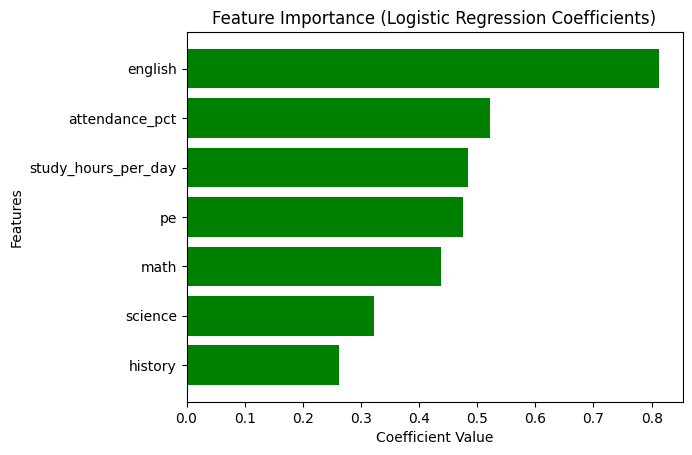

In [26]:
# Plot
features_sorted = [f for f, _ in feature_importance]
coefs_sorted = [c for _, c in feature_importance]

colors = ['green' if c > 0 else 'red' for c in coefs_sorted]

plt.figure()
plt.barh(features_sorted, coefs_sorted, color=colors)
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.gca().invert_yaxis()

plt.savefig("plot8_feature_importance.png")
plt.show()

In [27]:
# Step 5 — Predict New Student

new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

new_scaled = scaler.transform(new_student)

prediction = model.predict(new_scaled)[0]
probability = model.predict_proba(new_scaled)[0]

label = "Pass" if prediction == 1 else "Fail"

print("\nNew Student Prediction:")
print(f"Prediction: {label}")
print(f"Probability [Fail, Pass]: {probability}")


New Student Prediction:
Prediction: Pass
Probability [Fail, Pass]: [0.09203526 0.90796474]


e:\massai\codes\assignments\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
